In [1]:
# ── Cell 1: Imports ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import optuna
from qiskit import QuantumCircuit
from qiskit_aer import Aer
from qiskit_aer import AerSimulator
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.metrics import root_mean_squared_error
from xgboost import XGBRegressor
from Preprocess import preprocess_data_window
from sklearn.model_selection import train_test_split
from catboost import CatBoostRegressor

optuna.logging.set_verbosity(optuna.logging.WARNING)


c:\Users\kaitl\anaconda3\envs\icequake-qrc\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ── Cell 2: Load data ────────────────────────────────────────────────────────
data_orig     = pd.read_csv("../Whillians-GPS-Data-and-Features.csv")
filtered_time = pd.read_csv("../filtered_time_to_next_event.csv")


In [3]:
# ── Cell 3: Preprocessing ────────────────────────────────────────────────────
n_previous_events = 20
n_qubits_base = 6

X_train, X_val, X_test, y_train, y_val, y_test, feature_cols = preprocess_data_window(
    filtered_time, data_orig, n_previous_events
)


print("NaN count per column:\n", X_train.isna().sum())
print("Total NaN:", X_train.isna().sum().sum())


X shape:  (2822, 126)
y shape:  (2822,)
NaN count per column:
 tide_deriv-0      0
form_fac-0        0
time_since-0      0
slip_size-0       0
high_t_evt-0      0
                 ..
form_fac-20       0
time_since-20     0
slip_size-20      0
high_t_evt-20     0
tide_height-20    0
Length: 126, dtype: int64
Total NaN: 0


In [4]:
# ── Cell 4: Config ───────────────────────────────────────────────────────────
QRC_CONFIG = {
    "num_layers_per_event": 2, 
    "shots":4096,
    "n_iterations": 5,
    "top_k": 3,
    "correlation_threshold": 0.0,
    "random_seed": 42,
}

CLASSICAL_MODEL_NAME = "Ridge"
n_previous_events = 20

print("QRC Config:", QRC_CONFIG)
print("Classical model:", CLASSICAL_MODEL_NAME)


QRC Config: {'num_layers_per_event': 2, 'shots': 4096, 'n_iterations': 5, 'top_k': 3, 'correlation_threshold': 0.0, 'random_seed': 42}
Classical model: Ridge


In [5]:
# ── Cell 5: Scaling ─────────────────────────────────────────────────────────
def scale_to_pi_range(X_train, X_val, X_test):
    train_min = X_train.min(axis=0)
    train_max = X_train.max(axis=0)
    denom = train_max - train_min
    denom[denom == 0] = 1.0

    def transform(X):
        scaled = (X - train_min) / denom
        scaled = np.clip(scaled, 0.0, 1.0)
        return scaled * np.pi

    return transform(X_train), transform(X_val), transform(X_test)


X_train_sel = X_train.to_numpy()
X_val_sel   = X_val.to_numpy()
X_test_sel  = X_test.to_numpy()

X_train_q, X_val_q, X_test_q = scale_to_pi_range(X_train_sel, X_val_sel, X_test_sel)

# Convert targets to numpy once here for use throughout
y_train_np = y_train.to_numpy() if hasattr(y_train, "to_numpy") else np.array(y_train)
y_val_np   = y_val.to_numpy()   if hasattr(y_val,   "to_numpy") else np.array(y_val)
y_test_np  = y_test.to_numpy()  if hasattr(y_test,  "to_numpy") else np.array(y_test)

n_qubits       = n_qubits_base
n_states       = 2 ** n_qubits
n_total_events = n_previous_events + 1

print(f"Input to quantum circuit: {X_train_q.shape}")
print(f"n_qubits: {n_qubits}, n_states: {n_states}")
print(f"Total events per sample: {n_total_events}")


Input to quantum circuit: (1692, 126)
n_qubits: 6, n_states: 64
Total events per sample: 21


In [6]:
# ── Cell 6: Regime labels loaded from a precomputed classification file ──────
# This replaces the K-Means + XGBoost classifier training. Instead of fitting a
# model on X features to predict "short"/"long" regime, we read the regime
# label for every event (in every split) directly from REGIME_LABELS_PATH.
# Everything downstream (masks, indices, centers, boundary) keeps the exact
# same variable names as before, so the rest of the notebook is unchanged.

import re
import numpy as np
import pandas as pd

# >>> UPDATE THIS to the actual path/filename of your regime-labels file <
REGIME_LABELS_PATH = "ridge_noiseless_fc_classifier_events.csv"

# ── Step 1: Parse the comment header for the K-Means cluster centers/boundary ─
# Expected format (first line of the file):
#   # short_center_s=45889.070209 long_center_s=83860.462382 boundary_s=64874.766296
with open(REGIME_LABELS_PATH, "r") as f:
    header_line = f.readline()

m = re.search(
    r"short_center_s=([\d.eE+-]+)\s+long_center_s=([\d.eE+-]+)\s+boundary_s=([\d.eE+-]+)",
    header_line,
)
if m is None:
    raise ValueError(f"Could not parse cluster centers from header line: {header_line!r}")

short_center_s, long_center_s, boundary_s = (float(g) for g in m.groups())
centers  = np.array([short_center_s, long_center_s])
boundary = boundary_s

print(f"Loaded regime centers — Short: {centers[0]:.0f} s, Long: {centers[1]:.0f} s")
print(f"Decision boundary (from file): {boundary:.0f} s")

# ── Step 2: Load the per-event labels ─────────────────────────────────────────
# Delimiter is auto-detected (comma, tab, or run of whitespace all work) since
# different exports of this file may use different separators. The comment
# header on row 1 is skipped; row 2 has the real column headers.
regime_df = pd.read_csv(REGIME_LABELS_PATH, skiprows=1, sep=None, engine="python")

# Clean up column names (strip whitespace) and drop any fully-empty / unnamed
# trailing columns that can appear from trailing delimiters in the source file.
regime_df.columns = [str(c).strip() for c in regime_df.columns]
regime_df = regime_df.loc[:, ~regime_df.columns.str.match(r"^Unnamed")]
regime_df = regime_df.dropna(axis=1, how="all")

required_cols = {"split", "event_index", "y_true_ttns_s", "regime_label", "regime"}
missing = required_cols - set(regime_df.columns)
if missing:
    raise ValueError(
        f"Regime labels file is missing expected columns: {missing}\n"
        f"Columns actually found: {list(regime_df.columns)}\n"
        f"Check REGIME_LABELS_PATH and the file's delimiter/header row."
    )

# Normalize dtypes — some exports load these as strings/objects.
regime_df["split"]        = regime_df["split"].astype(str).str.strip()
regime_df["event_index"]  = pd.to_numeric(regime_df["event_index"])
regime_df["y_true_ttns_s"] = pd.to_numeric(regime_df["y_true_ttns_s"])
regime_df["regime_label"] = pd.to_numeric(regime_df["regime_label"]).astype(int)

def _labels_for_split(split_name, X_split, y_split_np):
    """Pull regime labels for one split, aligned by event_index, with a sanity
    check against the y values already produced by preprocess_data_window."""
    sub = (
        regime_df[regime_df["split"] == split_name]
        .sort_values("event_index")
        .reset_index(drop=True)
    )
    if len(sub) != len(X_split):
        raise ValueError(
            f"'{split_name}' split length mismatch: file has {len(sub)} rows, "
            f"but X_{split_name} has {len(X_split)} rows. Check that the file "
            f"was generated from the same preprocessing/split as this notebook."
        )
    file_y = sub["y_true_ttns_s"].to_numpy()
    if not np.allclose(file_y, y_split_np, atol=1e-6):
        n_mismatch = int(np.sum(~np.isclose(file_y, y_split_np, atol=1e-6)))
        print(
            f"  WARNING: {n_mismatch}/{len(file_y)} '{split_name}' y-values differ "
            f"between the file and this notebook's y_{split_name}. The two may not "
            f"be row-aligned — double-check event_index ordering before trusting "
            f"downstream results."
        )
    else:
        print(f"  '{split_name}' labels verified against y_{split_name} ({len(sub)} rows match).")
    return sub["regime_label"].to_numpy().astype(int)

y_clf_train     = _labels_for_split("train", X_train, y_train_np)
clf_val_labels  = _labels_for_split("val",   X_val,   y_val_np)
clf_test_labels = _labels_for_split("test",  X_test,  y_test_np)

print(f"Class distribution (train) — Short: {(y_clf_train==0).sum()}, Long: {(y_clf_train==1).sum()}")

# ── Step 3: Raw (unscaled) features — still used by the classical sub-regressors ─
X_train_raw = X_train.to_numpy()
X_val_raw   = X_val.to_numpy()
X_test_raw  = X_test.to_numpy()

# ── Step 4: Routing masks — now taken straight from the file, not a classifier ──
short_mask_train = y_clf_train == 0
long_mask_train  = y_clf_train == 1
short_mask_val   = clf_val_labels == 0
long_mask_val    = clf_val_labels == 1

short_test_idx = np.where(clf_test_labels == 0)[0]
long_test_idx  = np.where(clf_test_labels == 1)[0]
short_val_idx  = np.where(clf_val_labels  == 0)[0]
long_val_idx   = np.where(clf_val_labels  == 1)[0]

print(f"\nLabel distribution — Train: Short {short_mask_train.sum()}, Long {long_mask_train.sum()}")
print(f"Test routing  — Short: {len(short_test_idx)}, Long: {len(long_test_idx)}")
print(f"Val routing   — Short: {len(short_val_idx)},  Long: {len(long_val_idx)}")

Loaded regime centers — Short: 45889 s, Long: 83860 s
Decision boundary (from file): 64875 s
  'train' labels verified against y_train (1692 rows match).
  'val' labels verified against y_val (565 rows match).
  'test' labels verified against y_test (565 rows match).
Class distribution (train) — Short: 1054, Long: 638

Label distribution — Train: Short 1054, Long 638
Test routing  — Short: 348, Long: 217
Val routing   — Short: 356,  Long: 209


In [7]:
# ── Cell 7: NN-TFI Hamiltonian (nearest-neighbour connectivity) ──────────────
# Switched from FC-TFI to Opt-NN-TFI (nearest-neighbour connectivity), following
# the NN-TFI-Noiseless notebook.
#
# Motivation (from Hamhoum et al. 2025, §6.3 + Fig. 10 / 12):
#   • FC-TFI circuit depth scales exponentially with qubit count (O(N^2) ZZ pairs
#     per Trotter step), reaching ~1561 layers / 3028 gates for 6 qubits.
#   • Opt-NN-TFI uses only nearest-neighbour RXX pairs and a single Trotter step,
#     giving ~543 layers for 6 qubits — and this depth stays CONSTANT as qubit
#     count grows (Fig. 12).
#   • Performance is statistically comparable to FC-TFI on both ENSO and Lorenz-63
#     (Fig. 10), while being far more noise-resilient on real hardware.
#   • n_trotter_steps=1: one first-order Trotterization step per evolution call,
#     matching the NN2-TFI / Opt-NN-TFI circuits shown in Fig. 4 of the paper.

def generate_ising_params(n_qubits, rng, J_std=0.5, h=0.5, t=0.1):
    """Sample random NN coupling constants J_{i,i+1} from N(0, J_std).

    Only adjacent pairs (i, i+1) are populated; all other entries remain 0.
    h and t defaults are tuned to the sweet-spot found in Fig. 11 of the paper
    (τ ∈ [0.1, 1], h = 0.5 with θ = 2hτ ∈ [0, π] giving meaningful rotation).
    """
    J = np.zeros((n_qubits, n_qubits))
    for i in range(n_qubits - 1):          # nearest-neighbour only
        J[i, i + 1] = rng.uniform(-0.5, 0.5)
    return J, h, t


def trotter_ising_layer(qc, n_qubits, J, h, t, n_trotter_steps=1):
    """First-order Trotterization of NN-TFI Hamiltonian.

    n_trotter_steps=1 matches the Opt-NN-TFI circuits in Fig. 4 of the paper.
    Each ZZ interaction is compiled as CX–RZ–CX (native on Heron R2).
    RX for the transverse field acts on every qubit.
    """
    dt = t / n_trotter_steps
    for _ in range(n_trotter_steps):
        # ZZ layer — only nearest-neighbour pairs
        for i in range(n_qubits - 1):
            if abs(J[i, i + 1]) > 1e-10:
                qc.cx(i, i + 1)
                qc.rz(2 * J[i, i + 1] * dt, i + 1)
                qc.cx(i, i + 1)
        # Transverse field — single-qubit RX on every qubit
        for i in range(n_qubits):
            qc.rx(2 * h * dt, i)


def encode_rotations(qc, data_sample, n_qubits):
    for i in range(n_qubits):
        qc.ry(float(data_sample[i]), i)


def build_reservoir_circuit_rotations(data_sample, ising_params, num_layers, n_qubits):
    J, h, t = ising_params
    qc = QuantumCircuit(n_qubits)

    for i in range(n_qubits):
        qc.h(i)

    encode_rotations(qc, data_sample, n_qubits)
    qc.barrier()

    for layer in range(num_layers):
        trotter_ising_layer(qc, n_qubits, J, h, t)
        qc.barrier()

        encode_rotations(qc, data_sample, n_qubits)
        qc.barrier()

        trotter_ising_layer(qc, n_qubits, J, h, t)
        qc.barrier()

    return qc


def generate_random_angles(num_layers, n_qubits, rng):
    return generate_ising_params(n_qubits, rng)


In [8]:
# ── Cell 8: Sequential (stateful) NN-TFI reservoir — persists across events ──
from qiskit.quantum_info import Statevector, SparsePauliOp

def build_event_step_circuit(data_sample, ising_params, num_layers, n_qubits, apply_initial_h):
    """Gates for ONE event only: optional initial H (event 0 only),
    then num_layers of [Trotter-Ising, Ry-encode, Trotter-Ising].
    This is evolved onto the RUNNING state, never reset."""
    J, h, t = ising_params
    qc = QuantumCircuit(n_qubits)
    if apply_initial_h:
        for i in range(n_qubits):
            qc.h(i)
    encode_rotations(qc, data_sample, n_qubits)
    for _ in range(num_layers):
        trotter_ising_layer(qc, n_qubits, J, h, t)
        encode_rotations(qc, data_sample, n_qubits)
        trotter_ising_layer(qc, n_qubits, J, h, t)
    return qc


def pauli_expectations_from_statevector(sv, n_qubits):
    """Exact (noiseless) expectation values — no shots, no collapse.
    Same feature layout as the old shot-based get_pauli_expectations:
    [Z x n_qubits, X x n_qubits, Y x n_qubits, ZZ_nn x n_qubits].

    ZZ correlators are nearest-neighbour only (i, i+1) on an OPEN chain,
    consistent with the NN-TFI coupling topology (only adjacent qubits are
    actually coupled in the Hamiltonian). The wrap-around pair (n_qubits-1, 0)
    is left at 0, matching the Opt-NN-TFI observable set used in the
    NN-TFI-Noiseless notebook's shot-based get_pauli_expectations_from_counts.
    """
    expectations = np.zeros(3 * n_qubits)
    for basis_idx, basis in enumerate(['Z', 'X', 'Y']):
        for q in range(n_qubits):
            label = ['I'] * n_qubits
            label[n_qubits - 1 - q] = basis  # Qiskit little-endian qubit order
            op = SparsePauliOp(''.join(label))
            expectations[basis_idx * n_qubits + q] = sv.expectation_value(op).real

    zz_correlators = np.zeros(n_qubits)
    for i in range(n_qubits - 1):          # nearest-neighbour only, open chain
        j = i + 1
        label = ['I'] * n_qubits
        label[n_qubits - 1 - i] = 'Z'
        label[n_qubits - 1 - j] = 'Z'
        op = SparsePauliOp(''.join(label))
        zz_correlators[i] = sv.expectation_value(op).real
    # Wrap-around (n_qubits-1, 0) kept at 0 for open-chain NN topology.

    return np.concatenate([expectations, zz_correlators])


def run_quantum_reservoir_pauli_sequential(
    X_data, angle_bank, num_layers, n_qubits, n_total_events
):
    """
    Stateful NN-TFI reservoir: ONE quantum state per sample, driven sequentially
    through all n_total_events event encodings. The state is never reset between
    events, so later events' readouts are genuinely conditioned on earlier ones —
    this is the actual fading-memory mechanism QRC is supposed to exploit.
    """
    if hasattr(X_data, 'values'):
        X_data = X_data.to_numpy()

    m     = X_data.shape[0]
    n_obs = 3 * n_qubits + n_qubits
    pauli_matrix = np.zeros((m, n_total_events * n_obs))

    for sample_idx in range(m):
        sv = Statevector.from_label('0' * n_qubits)

        for event_idx in range(n_total_events):
            start_col = event_idx * n_qubits
            end_col   = start_col + n_qubits
            data_sample  = X_data[sample_idx, start_col:end_col]
            ising_params = angle_bank[event_idx]

            step_circuit = build_event_step_circuit(
                data_sample, ising_params, num_layers, n_qubits,
                apply_initial_h=(event_idx == 0),
            )
            sv = sv.evolve(step_circuit)   # <-- state persists, no reset

            obs_vals = pauli_expectations_from_statevector(sv, n_qubits)
            pauli_matrix[
                sample_idx,
                event_idx * n_obs:(event_idx + 1) * n_obs
            ] = obs_vals

        if sample_idx % 50 == 0:
            print(f"  Sample {sample_idx + 1}/{m} done", end="\r")

    print()
    return pauli_matrix


In [9]:
# ── Cell 9: Model registry ────────────────────────────────────────────────────
def get_model_registry():
    return {
        "Ridge": {
            "optuna_fn": lambda trial: {
                "alpha": trial.suggest_float("alpha", 1e-2, 1e8, log=True),
            },
            "fixed_params": {},
            "build_fn": lambda params: Ridge(**params),
            "optuna_fit_fn": lambda model, Xt, yt: model.fit(Xt, yt),
            "fit_fn": lambda model, Xt, yt, Xv, yv: model.fit(Xt, yt),
            "shap_explainer": "linear",
        },
        "XGBoost": {
            "optuna_fn": lambda trial: {
                "learning_rate":    trial.suggest_float("learning_rate", 0.005, 0.15, log=True),
                "max_depth":        trial.suggest_int("max_depth", 2, 8),
                "subsample":        trial.suggest_float("subsample", 0.5, 1.0),
                "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
                "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
                "reg_alpha":        trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
                "reg_lambda":       trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
            },
            "fixed_params": {
                "objective":   "reg:squarederror",
                "n_estimators": 2000,
                "random_state": 42,
                "tree_method":  "hist",
            },
            "build_fn": lambda params: XGBRegressor(**params),
            # optuna_fit_fn: plain fit — used only inside Optuna CV objectives.
            "optuna_fit_fn": lambda model, Xt, yt: model.fit(Xt, yt, verbose=False),
            # fit_fn: plain fit, no eval_set, no early stopping.
            # n_estimators is fixed; val is kept clean for iteration ranking.
            "fit_fn": lambda model, Xt, yt, Xv, yv: model.fit(Xt, yt, verbose=False),
            "shap_explainer": "tree",
        },
        "CatBoost": {
            "optuna_fn": lambda trial: {
                "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
                "depth":         trial.suggest_int("depth", 2, 8),
            },
            "fixed_params": {
                "iterations":          100,
                "loss_function":       "RMSE",
                "eval_metric":         "RMSE",
                "random_seed":         42,
                "verbose":             False,
                "allow_writing_files": False,
            },
            "build_fn": lambda params: CatBoostRegressor(**params),
            # plain fit, no eval_set 
            "optuna_fit_fn": lambda model, Xt, yt: model.fit(Xt, yt),
            "fit_fn": lambda model, Xt, yt, Xv, yv: model.fit(Xt, yt),
            "shap_explainer": "tree",
        },
        "RandomForest": {
            "optuna_fn": lambda trial: {
                "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
                "max_depth":    trial.suggest_int("max_depth", 2, 10),
            },
            "fixed_params": {"random_state": 42},
            "build_fn": lambda params: RandomForestRegressor(**params),
            "optuna_fit_fn": lambda model, Xt, yt: model.fit(Xt, yt),
            "fit_fn": lambda model, Xt, yt, Xv, yv: model.fit(Xt, yt),
            "shap_explainer": "tree",
        },
    }


registry = get_model_registry()
print(f"Available models: {list(registry.keys())}")
print(f"Using: {CLASSICAL_MODEL_NAME}")


Available models: ['Ridge', 'XGBoost', 'CatBoost', 'RandomForest']
Using: Ridge


In [10]:
# ── Cell 10: Single iteration — pre-classified regime-specific reservoirs ──────
def run_single_qrc_iteration(
    iteration_idx,
    X_train_q, X_val_q, X_test_q,
    y_train, y_val, y_test,
    n_qubits, config, model_name, registry,
):
    num_layers     = config["num_layers_per_event"]
    seed           = config["random_seed"] + iteration_idx
    n_total_events = n_previous_events + 1
    n_obs          = 3 * n_qubits + n_qubits  # 24
    # NOTE: config["shots"] is no longer used — the sequential reservoir uses
    # exact statevector expectation values, not shot sampling.

    rng_short = np.random.default_rng(seed)
    rng_long  = np.random.default_rng(seed + 10000)

    angle_bank_short = [
        generate_random_angles(num_layers, n_qubits, rng_short)
        for _ in range(n_total_events)
    ]
    angle_bank_long = [
        generate_random_angles(num_layers, n_qubits, rng_long)
        for _ in range(n_total_events)
    ]

    # ── Step 1: Split train/val by classifier-predicted regime ────────────────
    # short_mask_train/val are derived from classifier predictions on X (Cell 6)
    X_tr_short = X_train_q[short_mask_train]
    X_tr_long  = X_train_q[long_mask_train]
    X_vl_short = X_val_q[short_mask_val]
    X_vl_long  = X_val_q[long_mask_val]

    y_tr_short = y_train_np[short_mask_train]
    y_tr_long  = y_train_np[long_mask_train]
    y_vl_short = y_val_np[short_mask_val]
    y_vl_long  = y_val_np[long_mask_val]

    print(f"  Short regime — train: {len(y_tr_short)}, val: {len(y_vl_short)}")
    print(f"  Long  regime — train: {len(y_tr_long)},  val: {len(y_vl_long)}")

    # ── Step 2: Run SHORT regime reservoir (sequential/stateful) ──────────────
    print(f"  Running SHORT NN-TFI reservoir on train ({len(X_tr_short)} samples)...")
    P_tr_short = run_quantum_reservoir_pauli_sequential(
        X_tr_short, angle_bank_short, num_layers, n_qubits, n_total_events
    )
    print(f"  Running SHORT NN-TFI reservoir on val ({len(X_vl_short)} samples)...")
    P_vl_short = run_quantum_reservoir_pauli_sequential(
        X_vl_short, angle_bank_short, num_layers, n_qubits, n_total_events
    )
    print(f"  Running SHORT NN-TFI reservoir on test ({len(short_test_idx)} samples)...")
    P_te_short = run_quantum_reservoir_pauli_sequential(
        X_test_q[short_test_idx], angle_bank_short, num_layers, n_qubits, n_total_events
    )

    # ── Step 3: Run LONG regime reservoir (sequential/stateful) ───────────────
    print(f"  Running LONG NN-TFI reservoir on train ({len(X_tr_long)} samples)...")
    P_tr_long = run_quantum_reservoir_pauli_sequential(
        X_tr_long, angle_bank_long, num_layers, n_qubits, n_total_events
    )
    print(f"  Running LONG NN-TFI reservoir on val ({len(y_vl_long)} samples)...")
    P_vl_long = run_quantum_reservoir_pauli_sequential(
        X_vl_long, angle_bank_long, num_layers, n_qubits, n_total_events
    )
    print(f"  Running LONG NN-TFI reservoir on test ({len(long_test_idx)} samples)...")
    P_te_long = run_quantum_reservoir_pauli_sequential(
        X_test_q[long_test_idx], angle_bank_long, num_layers, n_qubits, n_total_events
    )

    # ── Step 4: Quantum-only features with decay ──────────────────────────────
    H_tr_short = P_tr_short
    H_vl_short = P_vl_short
    H_te_short = P_te_short

    H_tr_long  = P_tr_long
    H_vl_long  = P_vl_long
    H_te_long  = P_te_long

    entry = registry[model_name]

    # ── Step 5: Tune and train SHORT sub-regressor ────────────────────────────
    from sklearn.model_selection import KFold

    _n_cv_folds = 3   

    def _cv_mae(entry, params, H_tr, y_tr, rng_seed):
        """Return mean CV-MAE over KFold splits of the training data."""
        kf     = KFold(n_splits=_n_cv_folds, shuffle=True, random_state=rng_seed)
        maes   = []
        optuna_fit = entry.get("optuna_fit_fn", lambda m, Xt, yt: m.fit(Xt, yt))
        for fold_tr, fold_vl in kf.split(H_tr):
            m = entry["build_fn"](params)
            optuna_fit(m, H_tr[fold_tr], y_tr[fold_tr])
            maes.append(mean_absolute_error(y_tr[fold_vl], m.predict(H_tr[fold_vl])))
        return float(np.mean(maes))

    def short_objective(trial):
        tuned  = entry["optuna_fn"](trial)
        params = {**entry["fixed_params"], **tuned}
        return _cv_mae(entry, params, H_tr_short, y_tr_short, seed)

    short_study = optuna.create_study(
        direction="minimize",
        sampler=optuna.samplers.TPESampler(seed=seed),
    )
    short_study.optimize(short_objective, n_trials=30)

    # Final refit on full train split; val used only for early stopping
    short_tuned  = entry["optuna_fn"](short_study.best_trial)
    short_params = {**entry["fixed_params"], **short_tuned}
    model_short  = entry["build_fn"](short_params)
    entry["fit_fn"](model_short, H_tr_short, y_tr_short, H_vl_short, y_vl_short)

    # ── Step 6: Tune and train LONG sub-regressor ─────────────────────────────
    def long_objective(trial):
        tuned  = entry["optuna_fn"](trial)
        params = {**entry["fixed_params"], **tuned}
        return _cv_mae(entry, params, H_tr_long, y_tr_long, seed + 1)

    long_study = optuna.create_study(
        direction="minimize",
        sampler=optuna.samplers.TPESampler(seed=seed + 1),
    )
    long_study.optimize(long_objective, n_trials=30)

    long_tuned  = entry["optuna_fn"](long_study.best_trial)
    long_params = {**entry["fixed_params"], **long_tuned}
    model_long  = entry["build_fn"](long_params)
    entry["fit_fn"](model_long, H_tr_long, y_tr_long, H_vl_long, y_vl_long)

    short_val_mae = mean_absolute_error(y_vl_short, model_short.predict(H_vl_short))
    long_val_mae  = mean_absolute_error(y_vl_long,  model_long.predict(H_vl_long))
    print(f"  Short regime val MAE: {short_val_mae:.2f}s")
    print(f"  Long  regime val MAE: {long_val_mae:.2f}s")

    # ── Step 7: Test predictions routed by classifier ─────────────────────────
    test_pred = np.empty(len(X_test_q))
    if len(short_test_idx) > 0:
        test_pred[short_test_idx] = model_short.predict(H_te_short)
    if len(long_test_idx) > 0:
        test_pred[long_test_idx]  = model_long.predict(H_te_long)

    # ── Step 8: Val predictions using already-computed reservoir outputs ───────
    val_pred = np.empty(len(X_val_q))

    short_val_positions = {
        idx: pos for pos, idx in enumerate(np.where(short_mask_val)[0])
    }
    long_val_positions = {
        idx: pos for pos, idx in enumerate(np.where(long_mask_val)[0])
    }

    for idx in short_val_idx:
        assert idx in short_val_positions, (
            f"Val index {idx} was predicted short by classifier but missing from "
            f"short_mask_val — masks are inconsistent."
        )
        pos = short_val_positions[idx]
        val_pred[idx] = model_short.predict(H_vl_short[pos:pos+1])[0]

    for idx in long_val_idx:
        assert idx in long_val_positions, (
            f"Val index {idx} was predicted long by classifier but missing from "
            f"long_mask_val — masks are inconsistent."
        )
        pos = long_val_positions[idx]
        val_pred[idx] = model_long.predict(H_vl_long[pos:pos+1])[0]

    # ── Step 9: Metrics ───────────────────────────────────────────────────────
    return {
        "iteration":   iteration_idx,
        "val_r2":      r2_score(y_val_np, val_pred),
        "val_rmse":    root_mean_squared_error(y_val_np, val_pred),
        "val_mae":     mean_absolute_error(y_val_np, val_pred),
        "test_rmse":   root_mean_squared_error(y_test_np, test_pred),
        "test_mae":    mean_absolute_error(y_test_np, test_pred),
        "test_pred":   test_pred,
        "best_params": {"short": short_params, "long": long_params},
        "model_short":   model_short,
        "model_long":    model_long,
        "model":         model_short,            # backward-compat alias
        "P_train_short": P_tr_short,
        "P_val_short":   P_vl_short,
        "P_test_short":  P_te_short,
        "P_train_long":  P_tr_long,
        "P_val_long":    P_vl_long,
        "P_test_long":   P_te_long,
        # Legacy keys 
        "P_train": P_tr_short, "P_val": P_vl_short, "P_test": P_te_short,
    }

In [11]:
# ── Cell 11: Pipeline + run ───────────────────────────────────────────────────
def run_qrc_pipeline(
    X_train_q, X_val_q, X_test_q,
    y_train, y_val, y_test,
    n_qubits, config, model_name, registry,
):
    results = []
    for i in range(config["n_iterations"]):
        print(f"\nIteration {i + 1}/{config['n_iterations']}:")
        res = run_single_qrc_iteration(
            i,
            X_train_q, X_val_q, X_test_q,
            y_train, y_val, y_test,
            n_qubits, config, model_name, registry,
        )
        print(
            f"\tVal R2: {res['val_r2']:.4f} | Val RMSE: {res['val_rmse']:.2f} | "
            f"Val MAE: {res['val_mae']:.2f} | Test RMSE: {res['test_rmse']:.2f} | "
            f"Test MAE: {res['test_mae']:.2f}"
        )
        results.append(res)

    # ── Mean over all iterations (no val-based selection) ──────
    all_test_preds = np.array([r["test_pred"] for r in results])
    ensemble_pred  = all_test_preds.mean(axis=0)   # shape: (n_test,)
    ensemble_rmse  = root_mean_squared_error(y_test_np, ensemble_pred)
    ensemble_mae   = mean_absolute_error(y_test_np, ensemble_pred)
    ensemble_r2    = r2_score(y_test_np, ensemble_pred)

    print(f"\nEnsemble (all {len(results)} iterations — primary headline):")
    print(f"  Test RMSE: {ensemble_rmse:.2f}")
    print(f"  Test MAE:  {ensemble_mae:.2f}")
    print(f"  Test R2:   {ensemble_r2:.4f}")

    # ── Secondary: top-k by val MAE (optimistic upper bound) ─
    top_k          = config["top_k"]
    sorted_results = sorted(results, key=lambda r: r["val_mae"])
    top_results    = sorted_results[:top_k]
    top_indices    = [r["iteration"] for r in top_results]

    top_k_pred = np.mean([r["test_pred"] for r in top_results], axis=0)
    top_k_rmse = root_mean_squared_error(y_test_np, top_k_pred)
    top_k_mae  = mean_absolute_error(y_test_np, top_k_pred)
    top_k_r2   = r2_score(y_test_np, top_k_pred)

    print(f"\nTop-{top_k} ensemble by val MAE (optimistic — val used for selection):")
    print(f"  Iterations: {[i + 1 for i in top_indices]}")
    print(f"  Test RMSE: {top_k_rmse:.2f}")
    print(f"  Test MAE:  {top_k_mae:.2f}")
    print(f"  Test R2:   {top_k_r2:.4f}")

    # ── Per-regime test breakdown — classifier-predicted routing only ──────────
    short_clf_test = np.where(clf_test_labels == 0)[0]
    long_clf_test  = np.where(clf_test_labels == 1)[0]

    print(f"\n=== Ensemble Per-Regime Test MAE (classifier-predicted routing) ===")
    if len(short_clf_test) > 0:
        ensemble_short_mae = mean_absolute_error(
            y_test_np[short_clf_test], ensemble_pred[short_clf_test]
        )
        print(f"Short regime (classifier predicted, n={len(short_clf_test)}): "
              f"MAE = {ensemble_short_mae:.2f}s")
    if len(long_clf_test) > 0:
        ensemble_long_mae = mean_absolute_error(
            y_test_np[long_clf_test], ensemble_pred[long_clf_test]
        )
        print(f"Long  regime (classifier predicted, n={len(long_clf_test)}):  "
              f"MAE = {ensemble_long_mae:.2f}s")


    return results, ensemble_pred, top_indices


all_results, ensemble_pred, top_indices = run_qrc_pipeline(
    X_train_q, X_val_q, X_test_q,
    y_train, y_val, y_test,
    n_qubits, QRC_CONFIG,
    "Ridge",
    registry,
)



Iteration 1/5:
  Short regime — train: 1054, val: 356
  Long  regime — train: 638,  val: 209
  Running SHORT NN-TFI reservoir on train (1054 samples)...
  Sample 1051/1054 done
  Running SHORT NN-TFI reservoir on val (356 samples)...
  Sample 351/356 done
  Running SHORT NN-TFI reservoir on test (348 samples)...
  Sample 301/348 done
  Running LONG NN-TFI reservoir on train (638 samples)...
  Sample 601/638 done
  Running LONG NN-TFI reservoir on val (209 samples)...
  Sample 201/209 done
  Running LONG NN-TFI reservoir on test (217 samples)...
  Sample 201/217 done
  Short regime val MAE: 9754.75s
  Long  regime val MAE: 15562.70s
	Val R2: 0.0496 | Val RMSE: 19560.69 | Val MAE: 11903.18 | Test RMSE: 17334.13 | Test MAE: 10302.05

Iteration 2/5:
  Short regime — train: 1054, val: 356
  Long  regime — train: 638,  val: 209
  Running SHORT NN-TFI reservoir on train (1054 samples)...
  Sample 1051/1054 done
  Running SHORT NN-TFI reservoir on val (356 samples)...
  Sample 351/356 done
  

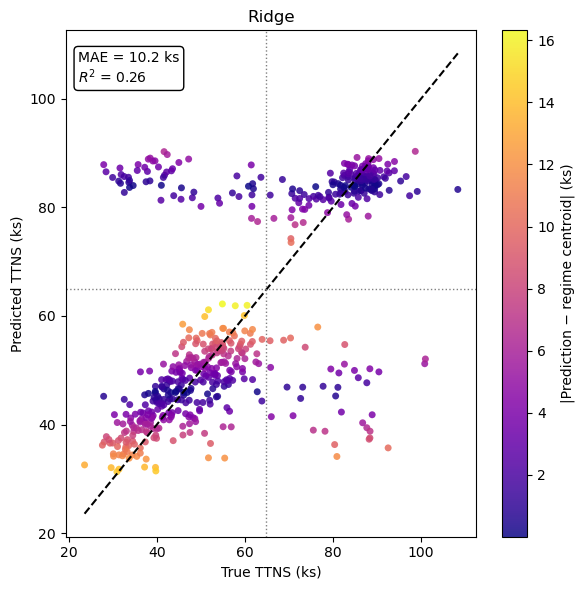

In [12]:
# ── Cell: Predicted vs True TTNS (Ridge QRC), single panel ────────────────────
import matplotlib.pyplot as plt

test_pred = ensemble_pred          # already computed by run_qrc_pipeline (Cell 12)
mae = mean_absolute_error(y_test_np, test_pred)
r2  = r2_score(y_test_np, test_pred)

# Regime centroid assigned to each test sample (from Cell 6's file-based labels)
assigned_center = np.where(clf_test_labels == 0, centers[0], centers[1])
color_vals = np.abs(test_pred - assigned_center) / 1000.0  # ks

fig, ax = plt.subplots(figsize=(6, 6))

sc = ax.scatter(
    y_test_np / 1000.0, test_pred / 1000.0,
    c=color_vals, cmap="plasma", s=25, alpha=0.85, edgecolors="none",
)

lims = [
    min(y_test_np.min(), test_pred.min()) / 1000.0,
    max(y_test_np.max(), test_pred.max()) / 1000.0,
]
ax.plot(lims, lims, "k--", linewidth=1.5)
ax.axhline(boundary / 1000.0, color="gray", linestyle=":", linewidth=1)
ax.axvline(boundary / 1000.0, color="gray", linestyle=":", linewidth=1)

ax.set_xlabel("True TTNS (ks)")
ax.set_ylabel("Predicted TTNS (ks)")
ax.set_title(f"{CLASSICAL_MODEL_NAME}")

ax.text(
    0.03, 0.96, f"MAE = {mae/1000:.1f} ks\n$R^2$ = {r2:.2f}",
    transform=ax.transAxes, va="top", fontsize=10,
    bbox=dict(boxstyle="round", facecolor="white", edgecolor="black"),
)

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("|Prediction − regime centroid| (ks)")

plt.tight_layout()
plt.show()